In [1]:
import opensim as osim
import numpy as np

In [3]:
def make_pendulum_model():
    model = osim.Model()
    model.setName('pendulum')
    model.setGravity(osim.Vec3(0, -9.81, 0))

    # Use ground and and a body to represent the pendulum
    ground = model.getGround()
    mass = 80 * 0.2 # 20% of body mass in kg
    length = 0.4    # length of pendulum in m
    head = osim.Body('head', mass, osim.Vec3(0), osim.Inertia(0.01, 0.01, 0.01))
    model.addBody(head)

    # Pin joint about Z-axis
    joint = osim.PinJoint('hinge', 
                        ground, osim.Vec3(0), osim.Vec3(0, 0, 1),
                        head, osim.Vec3(0, length, 0), osim.Vec3(0, 0, 1))
    model.addJoint(joint)

    # Define the joint coordinate
    coord = joint.getCoordinate(0)
    coord.setName('q_state')
    coord.setDefaultValue(0)  # initial angle
    coord.setDefaultSpeedValue(0)
    coord.setRangeMin(-np.pi)
    coord.setRangeMax(np.pi)

    # Define coordinate actuator
    act = osim.CoordinateActuator("q_state")
    act.setName("input_torque")
    act.setOptimalForce(1)
    act.setMinControl(-1e9)
    act.setMaxControl(1e9)
    model.addForce(act)

    # Define controller with a constant to +enable update of the torque in each step
    ctrl = osim.PrescribedController()
    ctrl.setName("torque_controller")
    ctrl.addActuator(act)
    func = osim.Constant(0)
    func.setName("torque")
    ctrl.prescribeControlForActuator("input_torque", func)
    model.addController(ctrl)

    # Finalize and initialize the model
    state = model.initSystem()
    coord.setLocked(state, False)
    
    manager = osim.Manager(model)
    manager.setIntegratorAccuracy(1e-6)
    manager.initialize(state)

    model.printToXML('v1_pendulum_model.osim')

    return {
        'model': model,
        'state': state,
        'coord': coord,
        'controller': ctrl,
        'function': func,
        'manager': manager
    }

def set_initial_conditions(env, q0, omega0):
    coord = env['coord']
    state = env['state']
    coord.setValue(state, q0, enforceContraints=False)
    coord.setSpeedValue(state, omega0)
    env['model'].realizeVelocity(state)
    return state

In [4]:
# OpenSim setup
env = make_pendulum_model()
state = set_initial_conditions(env, q0=np.pi/9, omega0=0)

model = env['model']
coord = env['coord']
func = env['function']
ctrl = env['controller']
manager = env['manager']

t = state.getTime()
tf = 2
dt = 0.001

ts = []
qs = []

In [5]:
state = manager.getState()
q_state = coord.getValue(state)
q_state

0.0

In [6]:
manager.integrate(1)

<opensim.simbody.State; proxy of <Swig Object of type 'SimTK::State *' at 0x7c3355b77bd0> >

In [7]:
state = manager.getState()
q_state = coord.getValue(state)
q_state

-1.427309632352417e-16

In [8]:
func.setValue(50)  # set constant torque to 50 Nm

# get the torque value from the controller


In [9]:
#func.setValue(300)  # Set constant torque (Nm)

# Apply torque and simulate

while t < tf:
    state = manager.getState()
    q_state = coord.getValue(state)
    omega_state = coord.getSpeedValue(state)
    print(f"t={t:.3f}, q={q_state:.3f}, omega={omega_state:.3f}")
    ts.append(t)
    qs.append(q_state)
    manager.integrate(t + dt)
    t += dt

t=0.000, q=-0.000, omega=0.000
t=0.001, q=-0.000, omega=0.000
t=0.002, q=-0.000, omega=0.000
t=0.003, q=-0.000, omega=0.000
t=0.004, q=-0.000, omega=0.000
t=0.005, q=-0.000, omega=0.000
t=0.006, q=-0.000, omega=0.000
t=0.007, q=-0.000, omega=0.000
t=0.008, q=-0.000, omega=0.000
t=0.009, q=-0.000, omega=0.000
t=0.010, q=-0.000, omega=0.000
t=0.011, q=-0.000, omega=0.000
t=0.012, q=-0.000, omega=0.000
t=0.013, q=-0.000, omega=0.000
t=0.014, q=-0.000, omega=0.000
t=0.015, q=-0.000, omega=0.000
t=0.016, q=-0.000, omega=0.000
t=0.017, q=-0.000, omega=0.000
t=0.018, q=-0.000, omega=0.000
t=0.019, q=-0.000, omega=0.000
t=0.020, q=-0.000, omega=0.000
t=0.021, q=-0.000, omega=0.000
t=0.022, q=-0.000, omega=0.000
t=0.023, q=-0.000, omega=0.000
t=0.024, q=-0.000, omega=0.000
t=0.025, q=-0.000, omega=0.000
t=0.026, q=-0.000, omega=0.000
t=0.027, q=-0.000, omega=0.000
t=0.028, q=-0.000, omega=0.000
t=0.029, q=-0.000, omega=0.000
t=0.030, q=-0.000, omega=0.000
t=0.031, q=-0.000, omega=0.000
t=0.032,

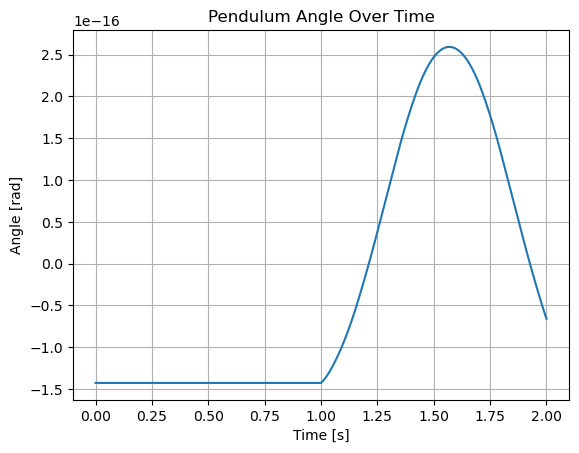

In [10]:
import matplotlib.pyplot as plt
plt.plot(ts, qs)
plt.xlabel('Time [s]')
plt.ylabel('Angle [rad]')
plt.title('Pendulum Angle Over Time')
plt.grid()
plt.show()
